In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings('ignore')

In [13]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples = 100, factor = .1, noise = .1)

X

array([[ 3.21580344e-01,  1.01465641e+00],
       [-6.83041942e-01, -5.90174033e-01],
       [ 4.18571523e-02, -6.42726647e-02],
       [-1.15148968e-01, -6.94929647e-02],
       [-7.44675808e-02,  8.81785027e-02],
       [-1.88799958e-02,  2.63807092e-01],
       [ 4.01377005e-01,  1.12897824e+00],
       [ 5.12379211e-02,  8.37731365e-02],
       [-1.39400915e-01, -1.06299518e-04],
       [-1.00927730e-01, -8.05998168e-02],
       [ 9.03855490e-01,  4.59819652e-01],
       [-1.38182794e-01,  1.80120892e-01],
       [-4.41834267e-02, -4.48646864e-02],
       [-1.03518495e+00,  1.47949139e-01],
       [ 5.87867580e-02, -1.09651130e-01],
       [ 1.13362047e+00, -1.71542944e-01],
       [-4.92779152e-03,  2.44773771e-02],
       [ 3.57541332e-01, -1.45198969e-01],
       [ 9.08903245e-01, -3.24684074e-01],
       [ 7.65514780e-01, -9.55246382e-01],
       [-8.75423404e-02,  1.28407189e-01],
       [-5.55816590e-02,  1.17220232e-01],
       [-7.08555139e-03,  1.70081292e-02],
       [ 1.

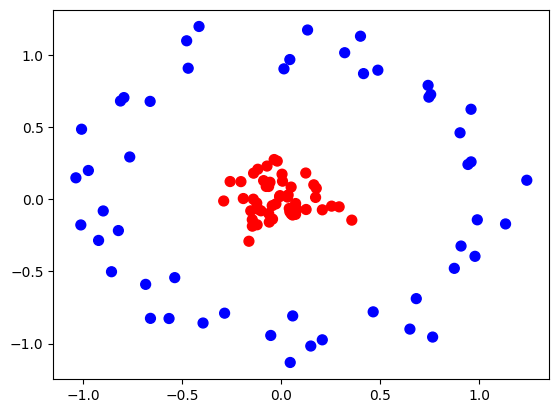

In [14]:
plt.scatter(X[:, 0], X[:, 1], c = y, s = 50, cmap = 'bwr')
plt.show()

### Applying Linear Suppor Vector Classifier

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 2), (20, 2), (80,), (20,))

In [16]:
classifier = SVC(kernel = 'linear')
classifier.fit(X_train,y_train)
y_pred =classifier.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.75

In [18]:
0.55
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

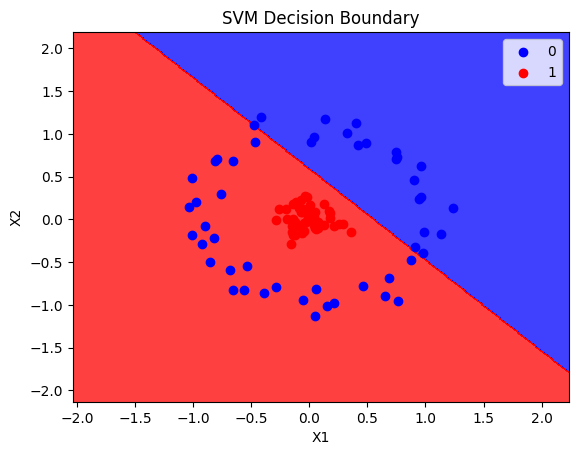

In [19]:
plot_decision_boundary(X, y, classifier)

In [20]:
def plot_3d_plot(X,y):
    r = np.exp(-(X**2).sum(1))
    ax = plt.subplot(projection = '3d')
    ax.scatter3D(X[:,0], X[:,1], r, c = y, s = 100, cmap = 'bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')

    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

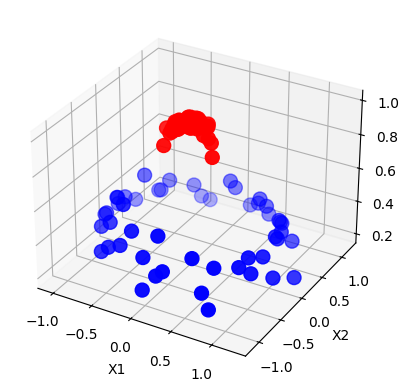

In [21]:
plot_3d_plot(X, y)

## Applying Radial-basis Function Kernel Trick

In [22]:
rbf_classifier = SVC(kernel = 'rbf')
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)
accuracy_score(y_test, y_pred)


1.0

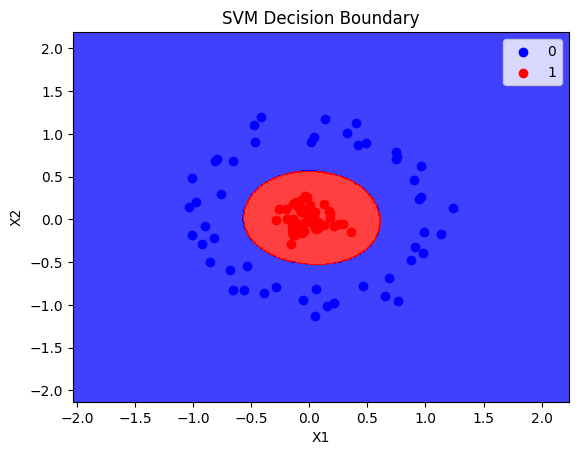

In [23]:
plot_decision_boundary(X, y, rbf_classifier)

## Applying Poly kernel

In [28]:
poly_classifier = SVC(kernel = 'poly', degree = 2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

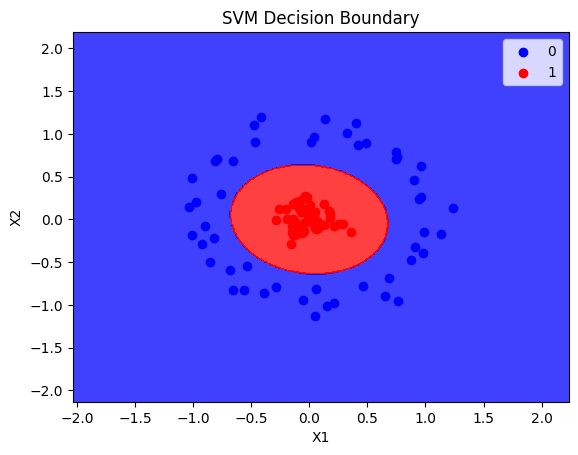

In [29]:
plot_decision_boundary(X, y, poly_classifier)